## Imports and SEED

In [1]:
import os
import random
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

## Path

In [2]:
from dotenv import load_dotenv

load_dotenv()

DATA_DIR = Path(os.environ["DATA_DIR"])
WEIGHTS_DIR = Path(os.environ["WEIGHTS_DIR"])

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


## Params


In [3]:
MODEL_NAME = "beit_base_patch16_224.in22k_ft_in22k"  # timm model id (used for config, not download)
IMG_SIZE = 224
NUM_CLASSES = 15  

# Fine-tuning strategy: unfreeze last N transformer blocks + head
NUM_UNFROZEN_BLOCKS = 4

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 64
NUM_WORKERS = 8

NUM_EPOCHS = 20
LR_HEAD = 1e-3        # higher LR for newly initialized head
LR_BACKBONE = 1e-5    # lower LR for unfrozen backbone blocks
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 2

In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA A100 80GB PCIe
VRAM: 85.0 GB


In [5]:
print(f"\nData dir exists: {DATA_DIR.exists()}")
print(f"Weights dir exists: {WEIGHTS_DIR.exists()}")



Data dir exists: True
Weights dir exists: True


## Data Exploration and Visualization

In [6]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
from PIL import Image

class_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir()])
class_names = [d.name for d in class_dirs]

print(f"Found {len(class_names)} classes:")
for c in class_names:
    print(" -", c)

if len(class_names) != NUM_CLASSES:
    print(f"\n WARNING: NUM_CLASSES in Cell 1 is {NUM_CLASSES}, "
          f"but found {len(class_names)} folders. Update Cell 1's NUM_CLASSES.")
else:
    print(f"\n NUM_CLASSES matches ({NUM_CLASSES})")

Found 15 classes:
 - Pepper__bell___Bacterial_spot
 - Pepper__bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Tomato_Bacterial_spot
 - Tomato_Early_blight
 - Tomato_Late_blight
 - Tomato_Leaf_Mold
 - Tomato_Septoria_leaf_spot
 - Tomato_Spider_mites_Two_spotted_spider_mite
 - Tomato__Target_Spot
 - Tomato__Tomato_YellowLeaf__Curl_Virus
 - Tomato__Tomato_mosaic_virus
 - Tomato_healthy

 NUM_CLASSES matches (15)


In [7]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

class_to_files = {}
for d in class_dirs:
    files = [f for f in d.iterdir() if f.suffix in VALID_EXTS]
    class_to_files[d.name] = files

counts = {c: len(files) for c, files in class_to_files.items()}
total_images = sum(counts.values())

print(f"\nTotal images: {total_images}")


Total images: 20638


In [8]:
print("\nPer-class counts:")

for c, n in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  {c:50s} {n:5d}")



Per-class counts:
  Tomato__Tomato_YellowLeaf__Curl_Virus               3208
  Tomato_Bacterial_spot                               2127
  Tomato_Late_blight                                  1909
  Tomato_Septoria_leaf_spot                           1771
  Tomato_Spider_mites_Two_spotted_spider_mite         1676
  Tomato_healthy                                      1591
  Pepper__bell___healthy                              1478
  Tomato__Target_Spot                                 1404
  Potato___Early_blight                               1000
  Potato___Late_blight                                1000
  Tomato_Early_blight                                 1000
  Pepper__bell___Bacterial_spot                        997
  Tomato_Leaf_Mold                                     952
  Tomato__Tomato_mosaic_virus                          373
  Potato___healthy                                     152


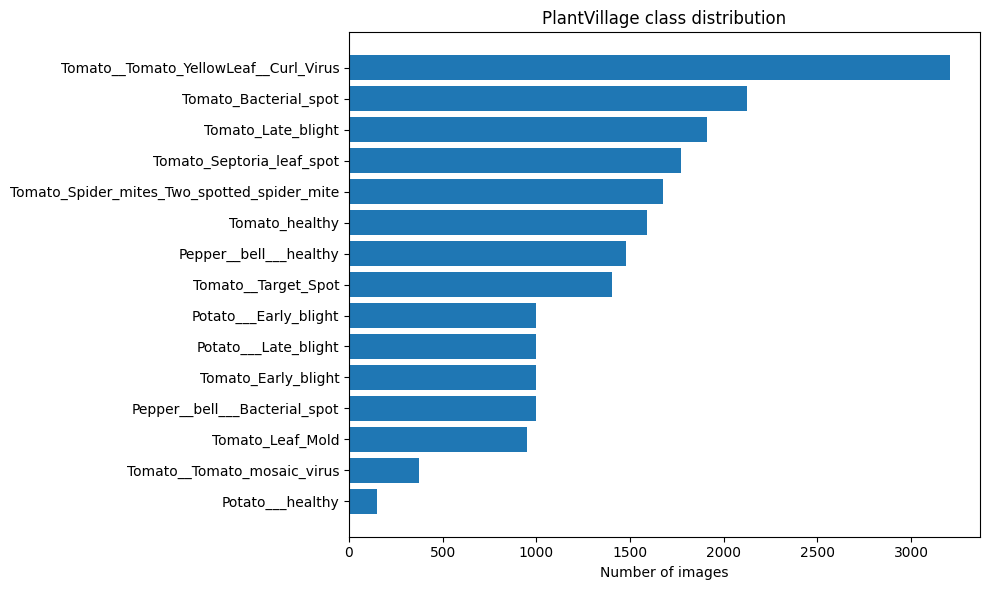

In [9]:
plt.figure(figsize=(10, 6))
sorted_items = sorted(counts.items(), key=lambda x: -x[1])
plt.barh([c for c, _ in sorted_items], [n for _, n in sorted_items])
plt.xlabel("Number of images")
plt.title("PlantVillage class distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

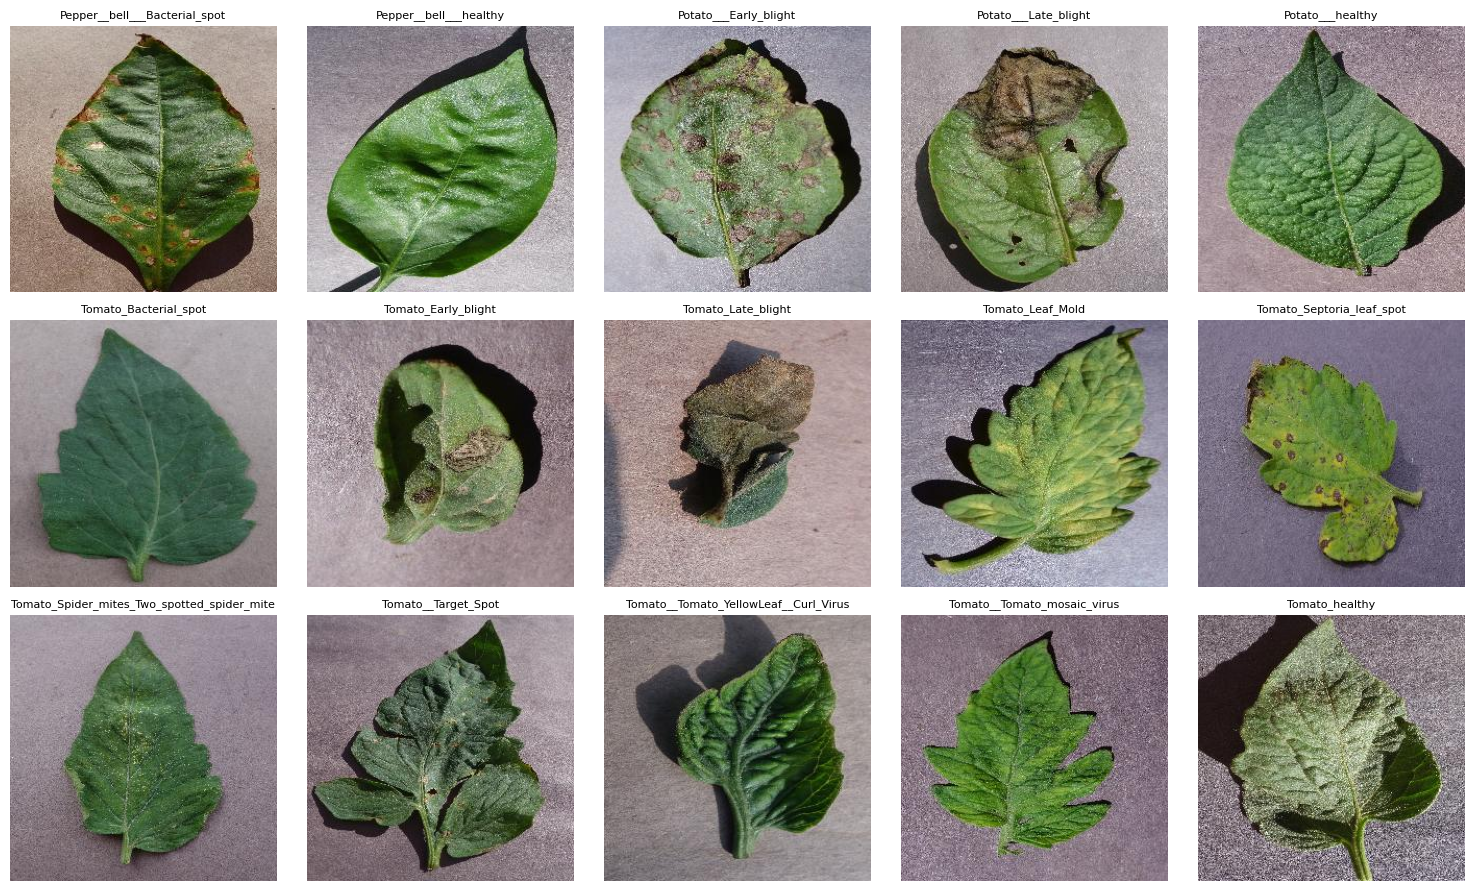

In [10]:
n_show = min(15, len(class_names))
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, c in enumerate(class_names[:n_show]):
    files = class_to_files[c]
    if not files:
        continue
    img_path = random.choice(files)
    img = Image.open(img_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(c, fontsize=8)
    axes[i].axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Train-Val Split 

In [11]:
from sklearn.model_selection import train_test_split

class_names = sorted(class_to_files.keys())          # fix a stable order
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

all_paths = []
all_labels = []
for c, files in class_to_files.items():
    label = class_to_idx[c]
    for f in files:
        all_paths.append(str(f))
        all_labels.append(label)

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"Total samples: {len(all_paths)}")
print(f"Classes: {len(class_names)}")


Total samples: 20638
Classes: 15


In [12]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    train_size=TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    train_size=VAL_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=temp_labels,
    random_state=SEED,
)

In [13]:
print(f"\nTrain: {len(train_paths)}  ({len(train_paths)/len(all_paths)*100:.1f}%)")
print(f"Val:   {len(val_paths)}  ({len(val_paths)/len(all_paths)*100:.1f}%)")
print(f"Test:  {len(test_paths)}  ({len(test_paths)/len(all_paths)*100:.1f}%)")



Train: 14446  (70.0%)
Val:   3096  (15.0%)
Test:  3096  (15.0%)


In [14]:
def per_class_counts(labels):
    counts = np.bincount(labels, minlength=len(class_names))
    return {idx_to_class[i]: int(counts[i]) for i in range(len(class_names))}

train_counts = per_class_counts(train_labels)
val_counts = per_class_counts(val_labels)
test_counts = per_class_counts(test_labels)

print(f"\n{'Class':50s} {'Train':>6s} {'Val':>6s} {'Test':>6s}")
for c in class_names:
    print(f"{c:50s} {train_counts[c]:6d} {val_counts[c]:6d} {test_counts[c]:6d}")



Class                                               Train    Val   Test
Pepper__bell___Bacterial_spot                         698    150    149
Pepper__bell___healthy                               1035    222    221
Potato___Early_blight                                 700    150    150
Potato___Late_blight                                  700    150    150
Potato___healthy                                      106     23     23
Tomato_Bacterial_spot                                1489    319    319
Tomato_Early_blight                                   700    150    150
Tomato_Late_blight                                   1336    286    287
Tomato_Leaf_Mold                                      666    143    143
Tomato_Septoria_leaf_spot                            1240    265    266
Tomato_Spider_mites_Two_spotted_spider_mite          1173    251    252
Tomato__Target_Spot                                   983    211    210
Tomato__Tomato_YellowLeaf__Curl_Virus                2245    48

In [15]:
split_data = {
    "class_names": class_names,
    "class_to_idx": class_to_idx,
    "train": {"paths": train_paths.tolist(), "labels": train_labels.tolist()},
    "val": {"paths": val_paths.tolist(), "labels": val_labels.tolist()},
    "test": {"paths": test_paths.tolist(), "labels": test_labels.tolist()},
}

split_file = OUTPUT_DIR / "data_split.json"
with open(split_file, "w") as f:
    json.dump(split_data, f)

print(f"\nSplit saved to: {split_file}")


Split saved to: outputs/data_split.json


## Transforms

In [16]:
from torchvision import transforms
from timm.data import resolve_model_data_config

data_cfg = resolve_model_data_config(MODEL_NAME)
MEAN = data_cfg["mean"]
STD = data_cfg["std"]
print(f"Using normalization -> mean: {MEAN}, std: {STD}")
print(f"Input size from config: {data_cfg['input_size']}")

Using normalization -> mean: (0.485, 0.456, 0.406), std: (0.229, 0.224, 0.225)
Input size from config: (3, 224, 224)


In [17]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

In [18]:
class PlantVillageDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]

        img = Image.open(img_path).convert("RGB")  # force RGB (safety net)

        if self.transform:
            img = self.transform(img)

        return img, label

In [19]:
train_dataset = PlantVillageDataset(train_paths, train_labels, transform=train_transform)
val_dataset = PlantVillageDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = PlantVillageDataset(test_paths, test_labels, transform=eval_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")
print(f"Test dataset size:  {len(test_dataset)}")

Train dataset size: 14446
Val dataset size:   3096
Test dataset size:  3096


In [20]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)


In [21]:
sample_imgs, sample_labels = next(iter(train_loader))
print(f"\nBatch image shape: {sample_imgs.shape}")   # [B, 3, 224, 224]
print(f"Batch label shape: {sample_labels.shape}")   # [B]
print(f"Label dtype: {sample_labels.dtype}")
print(f"Sample labels: {sample_labels[:10].tolist()}")


Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])
Label dtype: torch.int64
Sample labels: [11, 6, 8, 12, 7, 9, 12, 8, 10, 14]


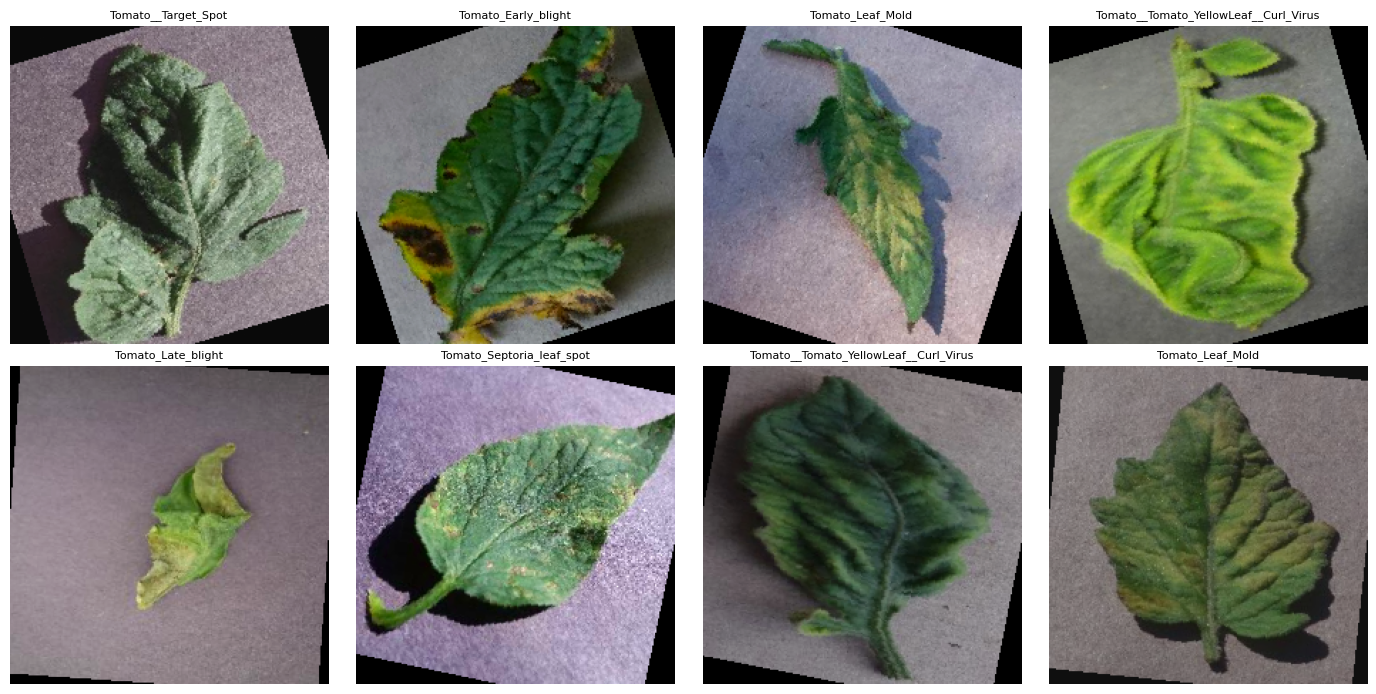

In [22]:
def denormalize(tensor, mean=MEAN, std=STD):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i in range(8):
    img = denormalize(sample_imgs[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img)
    axes[i].set_title(idx_to_class[sample_labels[i].item()], fontsize=8)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## Load Model Weights


In [23]:
from safetensors.torch import load_file as load_safetensors

safetensor_candidates = list(WEIGHTS_DIR.rglob("*.safetensors"))

print("Found safetensors files")

Found safetensors files


In [24]:
if len(safetensor_candidates) == 0:
    raise FileNotFoundError(f"No .safetensors file found under {WEIGHTS_DIR}")
elif len(safetensor_candidates) > 1:
    print("\n  Multiple safetensors files found — using the first one. "
          "Verify this is correct before proceeding.")


In [25]:
WEIGHTS_FILE = safetensor_candidates[0]
print(f"\nUsing weights file")


Using weights file


## Create Model

In [26]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,   # head is created fresh, sized for our 15 classes
)

In [27]:
state_dict = load_safetensors(str(WEIGHTS_FILE))
print(f"\nCheckpoint contains {len(state_dict)} tensors")


Checkpoint contains 211 tensors


In [28]:
model_state = model.state_dict()
filtered_state_dict = {}
skipped_keys = []

for k, v in state_dict.items():
    if k in model_state and model_state[k].shape == v.shape:
        filtered_state_dict[k] = v
    else:
        skipped_keys.append(k)

print(f"\nMatched {len(filtered_state_dict)} / {len(state_dict)} tensors")
print(f"Skipped {len(skipped_keys)} tensors (shape mismatch or not in model):")
for k in skipped_keys:
    ckpt_shape = state_dict[k].shape
    model_shape = model_state[k].shape if k in model_state else "N/A"
    print(f"  - {k}: checkpoint={tuple(ckpt_shape)} vs model={model_shape}")


Matched 197 / 211 tensors
Skipped 14 tensors (shape mismatch or not in model):
  - blocks.0.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.1.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.10.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.11.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.2.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.3.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.4.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.5.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.6.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.7.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.8.attn.relative_position_index: checkpoint=(197, 197) vs model=N/A
  - blocks.9.attn.relative_position_index: checkpoint=(197, 

In [29]:
missing, unexpected = model.load_state_dict(filtered_state_dict, strict=False)

print(f"\nMissing keys after load (expected: head.weight, head.bias): {missing}")
print(f"Unexpected keys after load (should be empty): {unexpected}")



Missing keys after load (expected: head.weight, head.bias): ['head.weight', 'head.bias']
Unexpected keys after load (should be empty): []


In [30]:
print(f"\nModel head: {model.get_classifier()}")
print(f"Head output features: {model.get_classifier().out_features}")
assert model.get_classifier().out_features == NUM_CLASSES, "Head size mismatch!"

model = model.to(DEVICE)
print(f"\nModel loaded and moved to {DEVICE}")


Model head: Linear(in_features=768, out_features=15, bias=True)
Head output features: 15

Model loaded and moved to cuda


## Test Forward Pass

In [31]:
model.eval()
with torch.no_grad():
    dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_output = model(dummy_input)
print(f"\nForward pass output shape: {dummy_output.shape}")  # [2, 15]
assert dummy_output.shape == (2, NUM_CLASSES)
print(" Forward pass successful")


Forward pass output shape: torch.Size([2, 15])
 Forward pass successful


## Partial fine-tune

In [34]:
print("Top-level model modules:")
for name, _ in model.named_children():
    print(" -", name)

print(f"\nNumber of transformer blocks: {len(model.blocks)}")


for param in model.parameters():
    param.requires_grad = False


# Step 2: unfreeze the classification head (always trainable)
for param in model.get_classifier().parameters():
    param.requires_grad = True


# Step 3: unfreeze the last N transformer blocks
total_blocks = len(model.blocks)
unfreeze_from = total_blocks - NUM_UNFROZEN_BLOCKS

for i, block in enumerate(model.blocks):
    if i >= unfreeze_from:
        for param in block.parameters():
            param.requires_grad = True


# Step 4: also unfreeze the final norm layer (sits right before
# the head, so it should adapt alongside the unfrozen blocks)

if hasattr(model, "norm"):
    for param in model.norm.parameters():
        param.requires_grad = True


# Report: trainable vs frozen parameter counts
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
frozen_params = total_params - trainable_params

print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"Frozen params:    {frozen_params:,} ({frozen_params/total_params*100:.1f}%)")


# Detailed per-block trainable status
print(f"\nUnfreezing last {NUM_UNFROZEN_BLOCKS} of {total_blocks} blocks "
      f"(blocks {unfreeze_from} to {total_blocks - 1}):\n")

for i, block in enumerate(model.blocks):
    is_trainable = any(p.requires_grad for p in block.parameters())
    status = "TRAINABLE" if is_trainable else "frozen"
    print(f"  Block {i:2d}: {status}")

head_trainable = any(p.requires_grad for p in model.get_classifier().parameters())
print(f"\n  Head:        {'TRAINABLE' if head_trainable else 'frozen'}")

if hasattr(model, "norm"):
    norm_trainable = any(p.requires_grad for p in model.norm.parameters())
    print(f"  Final norm:  {'TRAINABLE' if norm_trainable else ' frozen'}")


# Sanity check: gradient flows correctly (frozen params get no grad)
model.train()
dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
dummy_labels = torch.tensor([0, 1]).to(DEVICE)
dummy_output = model(dummy_input)
loss = nn.functional.cross_entropy(dummy_output, dummy_labels)
loss.backward()

frozen_has_grad = any(
    p.grad is not None and p.grad.abs().sum() > 0
    for i, block in enumerate(model.blocks) if i < unfreeze_from
    for p in block.parameters()
)
print(f"\nSanity check — frozen blocks received gradients (should be False): {frozen_has_grad}")

model.zero_grad()  # clear the dummy gradients before real training
print("Freeze/unfreeze setup verified")

Top-level model modules:
 - patch_embed
 - pos_drop
 - blocks
 - norm
 - fc_norm
 - head_drop
 - head

Number of transformer blocks: 12

Total params:     85,773,519
Trainable params: 28,401,231 (33.1%)
Frozen params:    57,372,288 (66.9%)

Unfreezing last 4 of 12 blocks (blocks 8 to 11):

  Block  0: frozen
  Block  1: frozen
  Block  2: frozen
  Block  3: frozen
  Block  4: frozen
  Block  5: frozen
  Block  6: frozen
  Block  7: frozen
  Block  8: TRAINABLE
  Block  9: TRAINABLE
  Block 10: TRAINABLE
  Block 11: TRAINABLE

  Head:        TRAINABLE
  Final norm:   frozen

Sanity check — frozen blocks received gradients (should be False): False
Freeze/unfreeze setup verified


In [39]:
#Loss, Optimizer, Scheduler

import math
from torch.optim.lr_scheduler import LambdaLR

# Inverse frequency, normalized so weights average to ~1.0
class_weights = 1.0 / train_class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print(f"\nClass weights:")
for i, w in enumerate(class_weights.cpu().numpy()):
    print(f"  {idx_to_class[i]:50s} {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)


# Optimizer: separate param groups for head (higher LR) vs
# unfrozen backbone blocks/norm (lower LR) — only trainable params
head_params = list(model.get_classifier().parameters())
head_param_ids = set(id(p) for p in head_params)

backbone_params = [
    p for p in model.parameters()
    if p.requires_grad and id(p) not in head_param_ids
]

print(f"\nHead params: {sum(p.numel() for p in head_params):,}")
print(f"Unfrozen backbone params: {sum(p.numel() for p in backbone_params):,}")

optimizer = torch.optim.AdamW([
    {"params": head_params, "lr": LR_HEAD, "weight_decay": WEIGHT_DECAY},
    {"params": backbone_params, "lr": LR_BACKBONE, "weight_decay": WEIGHT_DECAY},
])


# Scheduler: linear warmup -> cosine decay, per-step (not per-epoch)
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

print(f"\nSteps per epoch: {steps_per_epoch}")
print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

print("Loss, optimizer, and scheduler configured")


Class weights:
  Pepper__bell___Bacterial_spot                      0.799
  Pepper__bell___healthy                             0.539
  Potato___Early_blight                              0.797
  Potato___Late_blight                               0.797
  Potato___healthy                                   5.262
  Tomato_Bacterial_spot                              0.375
  Tomato_Early_blight                                0.797
  Tomato_Late_blight                                 0.418
  Tomato_Leaf_Mold                                   0.838
  Tomato_Septoria_leaf_spot                          0.450
  Tomato_Spider_mites_Two_spotted_spider_mite        0.476
  Tomato__Target_Spot                                0.567
  Tomato__Tomato_YellowLeaf__Curl_Virus              0.248
  Tomato__Tomato_mosaic_virus                        2.137
  Tomato_healthy                                     0.501

Head params: 11,535
Unfrozen backbone params: 28,389,696

Steps per epoch: 225
Total training step

## Training Loop (one epoch)

In [40]:
from tqdm.auto import tqdm


USE_AMP = True
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

GRAD_CLIP_NORM = 1.0  # prevents occasional large gradient spikes from unfrozen blocks

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr_head": [],
    "lr_backbone": [],
}

# Single training epoch
def train_one_epoch(model, loader, criterion, optimizer, scheduler, device, epoch, num_epochs):
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs} [train]", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        # Unscale before clipping (required when using AMP)
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad],
            max_norm=GRAD_CLIP_NORM,
        )

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()  # per-step scheduler, so step after every batch

        # ---- metrics ----
        batch_size = labels.size(0)
        preds = outputs.argmax(dim=1)
        correct = (preds == labels).sum().item()

        running_loss += loss.item() * batch_size
        running_correct += correct
        running_total += batch_size

        pbar.set_postfix({
            "loss": f"{running_loss / running_total:.4f}",
            "acc": f"{running_correct / running_total:.4f}",
            "lr_head": f"{optimizer.param_groups[0]['lr']:.2e}",
        })

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total

    return epoch_loss, epoch_acc

print("train_one_epoch() defined")
print(f"AMP enabled: {USE_AMP}")
print(f"Gradient clip norm: {GRAD_CLIP_NORM}")

train_one_epoch() defined
AMP enabled: True
Gradient clip norm: 1.0


## Validation / Evaluation Loop

In [42]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="val"):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc=f"[{desc}]", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        preds = outputs.argmax(dim=1)
        correct = (preds == labels).sum().item()

        running_loss += loss.item() * batch_size
        running_correct += correct
        running_total += batch_size

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

        pbar.set_postfix({
            "loss": f"{running_loss / running_total:.4f}",
            "acc": f"{running_correct / running_total:.4f}",
        })

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return epoch_loss, epoch_acc, all_preds, all_labels

print("evaluate() defined")

sanity_loss, sanity_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE, desc="sanity-check")
print(f"\nSanity check (untrained head) — Val loss: {sanity_loss:.4f}, Val acc: {sanity_acc:.4f}")
print(f"Expected acc near random baseline (~{1/NUM_CLASSES:.3f}) since head is untrained")

evaluate() defined


[sanity-check]:   0%|          | 0/49 [00:00<?, ?it/s]


Sanity check (untrained head) — Val loss: 2.9087, Val acc: 0.1111
Expected acc near random baseline (~0.067) since head is untrained
